# Lista 4 - DSP

## Aluno
João Mário C. I. Lago

In [5]:
!pip install -q dsp-ifsc numpy pandas matplotlib

## Imports

In [6]:
import numpy as np
from dsp_ifsc.signal import Signal
from dsp_ifsc.system import System

## Ex P3.19

An analog signal

$
x_a(t)=\sin(1000\pi t+\pi/4)
$

is sampled using the following sampling intervals. In each case, plot the spectrum of the resulting discrete-time signal.

1. $
   T_s = 0.1\text{ ms}
   $

2. $
   T_s = 1\text{ ms}
   $

3. $
   T_s = 0.01\text{ sec}
   $


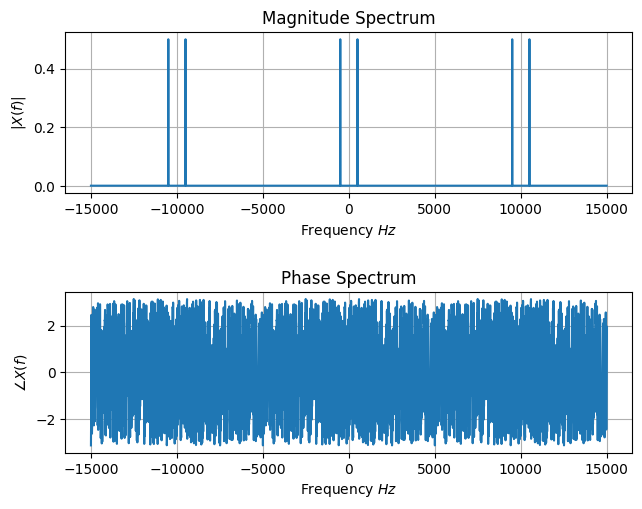

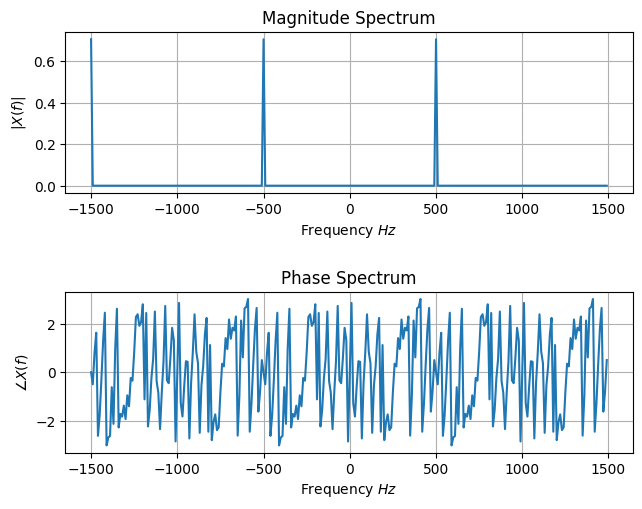

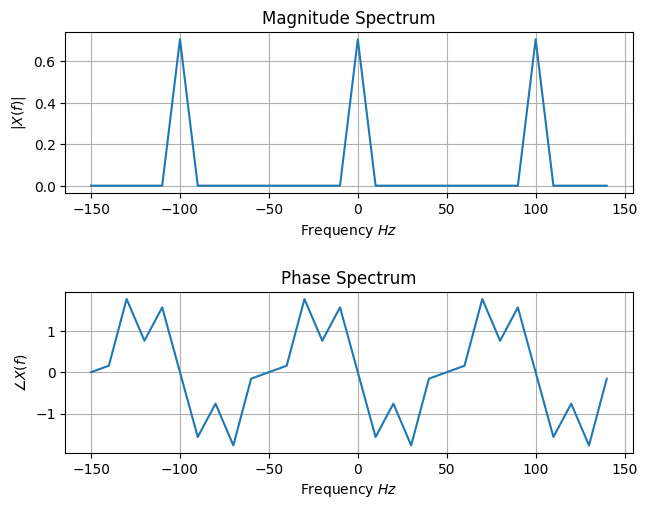

In [7]:
for Ts in [0.1e-3, 1e-3, 10e-3]:
    fs = 1 / Ts
    t = np.arange(0, 0.1, 1 / fs)

    x = Signal(
        np.sin(1000 * np.pi * t + np.pi / 4),
        t
    )

    X = x.spectrum_periodic(fs, periods=1)
    X.plot_frequency_domain(
        xlabel='Frequency $Hz$',
        magnitude_label=r'$|X(f)|$',
        phase_label=r'$\angle X(f)$',
    )


# Ex P3.20

$
f_s = 8000\text{ Hz}
$

$
T_s = \frac{1}{8000}
$

$
h[n] = (-0.9)^n u[n]
$

So:

$
H(e^{j\omega}) = \sum_{n=0}^{\infty}(-0.9)^n e^{-j\omega n}
$

$
H(e^{j\omega})=\frac{1}{1+0.9e^{-j\omega}}
$

---

### 1. Digital frequency for

$
x_a(t)=10\cos(10000\pi t)
$

Analog angular frequency:

$
\Omega = 10000\pi
$

Digital frequency:

$
\omega = \Omega T_s
$

$
\omega = \frac{10000\pi}{8000}
$

$
\omega = 1.25\pi
$

Since digital frequency is periodic modulo $(2\pi)$:

$
1.25\pi \equiv -0.75\pi
$

For cosine:

$
\cos(-0.75\pi n)=\cos(0.75\pi n)
$

So the effective digital frequency is:

$
\boxed{\omega = \frac{3\pi}{4}}
$

---

### 2. Steady-state output for

$
x_a(t)=10\cos(10000\pi t)
$

The sampled signal aliases to:

$
x[n]=10\cos\left(\frac{3\pi}{4}n\right)
$

Evaluate the filter at:

$\omega = \frac{3\pi}{4}$

$H(e^{j3\pi/4})= \frac{1}{1+0.9e^{-j3\pi/4}}$

Magnitude:

$
|H(e^{j3\pi/4})|
$

$
\frac{1}{|1+0.9e^{-j3\pi/4}|}
$

$
|H(e^{j3\pi/4})| \approx 1.364
$

Phase:

$
\angle H(e^{j3\pi/4}) \approx 1.051 \text{ rad}
$

So the output amplitude is:

$
10(1.364)=13.64
$

The analog output frequency after D/A is the aliased frequency:

$
f = 3000\text{ Hz}
$

$
\Omega = 2\pi(3000)=6000\pi
$

Therefore:

$
\boxed{
y_a(t) \approx 13.64\cos(6000\pi t + 1.051)
}
$

---

### 3. Steady-state output for

$
x_a(t)=5\sin(8000\pi t)
$

Analog frequency:

$
\Omega = 8000\pi
$

$
f = 4000\text{ Hz}
$

This is exactly the Nyquist frequency.

Sampling:

$
x[n]=5\sin(8000\pi nT_s)
$

$
x[n]=5\sin(\pi n)
$

But:

$
\sin(\pi n)=0
$

So:

$
x[n]=0
$

Therefore:

$
\boxed{y_a(t)=0}
$

---

### 4. Two other analog signals that give the same output as part 2

The original signal has:

$
f = 5000\text{ Hz}
$

With:

$
f_s = 8000\text{ Hz}
$

it aliases to:

$
f_{\text{alias}} = 3000\text{ Hz}
$

Any analog frequency of the form:

$
f = \pm 3000 + k8000
$

will give the same sampled cosine.

Two examples are:

$
\boxed{x_a(t)=10\cos(6000\pi t)}
$

because $f=3000\text{ Hz}$, and:

$
\boxed{x_a(t)=10\cos(22000\pi t)}
$

because $f=11000\text{ Hz}$, which also aliases to $3000\text{ Hz}$.

---

### 5. Prefilter to prevent aliasing

Use an **analog low-pass anti-aliasing filter** before the A/D converter.

The largest theoretical cutoff is the Nyquist frequency:

$
f_c = \frac{f_s}{2}
$

$
f_c = \frac{8000}{2}
$

$
\boxed{f_c = 4000\text{ Hz}}
$

In practice, the cutoff should be slightly below $4\text{ kHz}$ because real filters do not have an ideal brick-wall transition.

---


## Ex P3.19

Consider an analog signal

$$
x_a(t) = \cos(20\pi t), \qquad 0 \leq t \leq 1.
$$

It is sampled at

$$
T_s = 0.01,\ 0.05,\ \text{and}\ 0.1 \ \text{sec}
$$

intervals to obtain $x(n)$.

$$
\begin{aligned}
&1.\ \text{For each } T_s,\ \text{plot } x(n). \\
\\
&2.\ \text{Reconstruct the analog signal } y_a(t)\ \text{from the samples } x(n) \\
&\quad \text{using sinc interpolation (use } \Delta t = 0.001\text{) and determine} \\
&\quad \text{the frequency in } y_a(t)\ \text{from your plot. Ignore the end effects.} \\
\\
&3.\ \text{Reconstruct the analog signal } y_a(t)\ \text{from the samples } x(n) \\
&\quad \text{using cubic spline interpolation, and determine the frequency} \\
&\quad \text{in } y_a(t)\ \text{from your plot. Again, ignore the end effects.} \\
\\
&4.\ \text{Comment on your results.}
\end{aligned}
$$

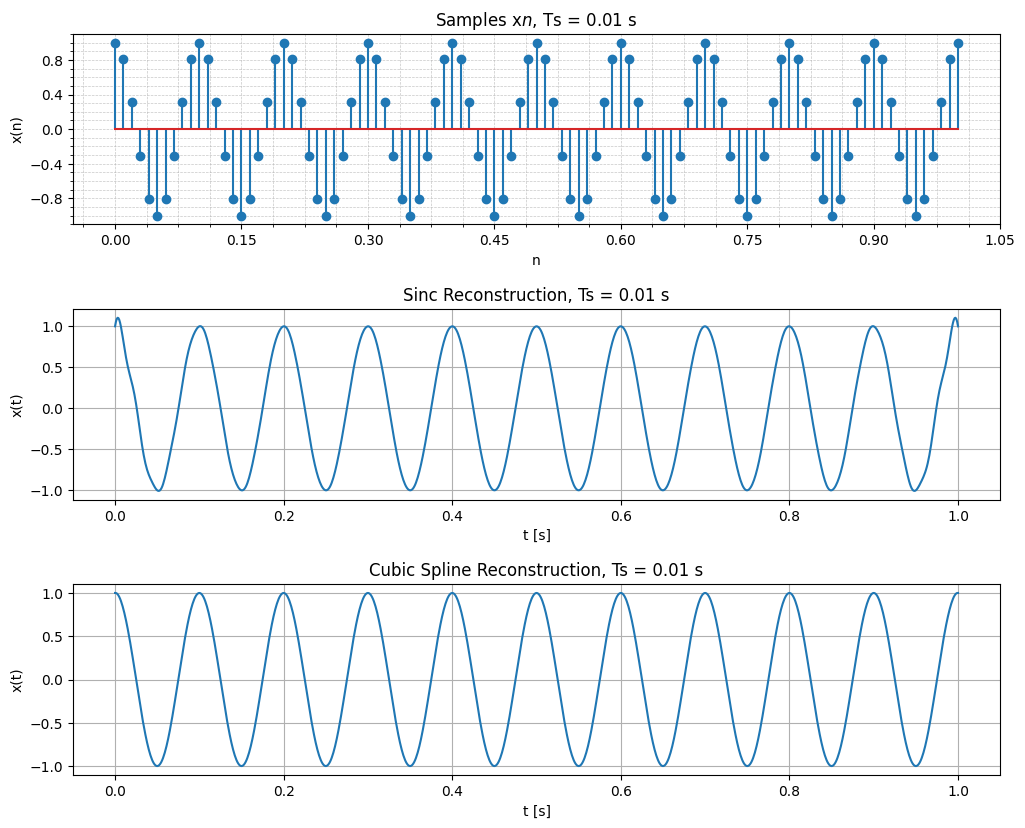

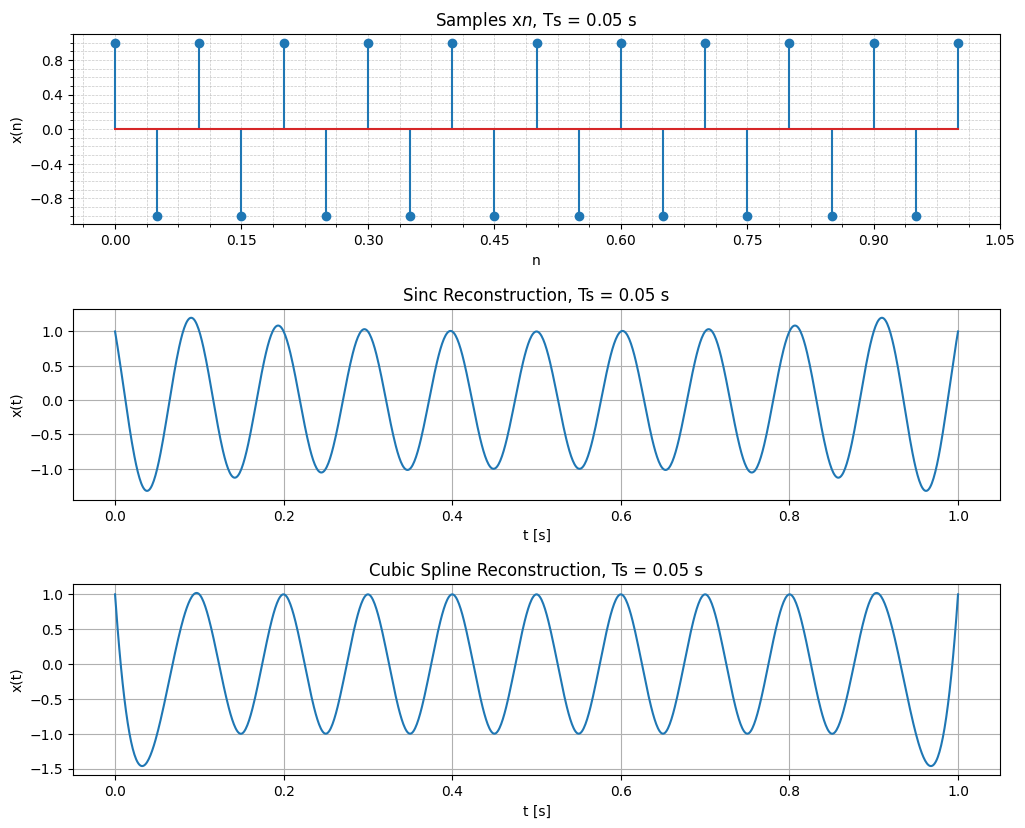

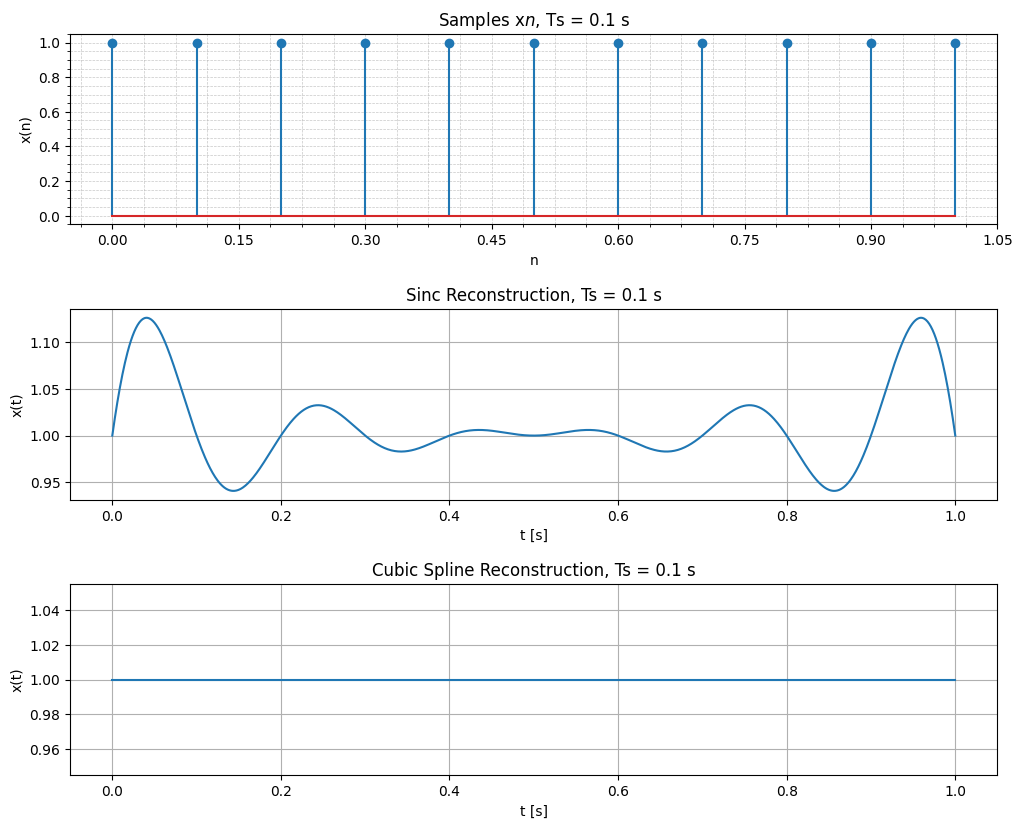

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Analog signal
def xa(t):
    return np.cos(20 * np.pi * t)

Ts_values = [0.01, 0.05, 0.1]

# Fine reconstruction grid
dt = 0.001
t_fine = np.arange(0, 1 + dt, dt)

for Ts in Ts_values:
    # Sampling instants
    t_samples = np.arange(0, 1 + Ts, Ts)

    # Sampled signal
    x_samples = xa(t_samples)
    x = Signal(x_samples, t_samples)

    # Reconstructions
    y_sinc = x.sinc_reconstruct(t_fine, Ts)
    y_spline = x.cubic_spline_reconstruct(t_fine)

    # Plot
    fig, axs = plt.subplots(3, 1, figsize=(10, 8))
    fig.tight_layout(h_pad=4.0)

    x.stem(
        title=f"Samples x[n], Ts = {Ts} s",
        plot=axs[0],
        auto_plot=False
    )

    y_sinc.plot_continuous(
        title=f"Sinc Reconstruction, Ts = {Ts} s",
        plot=axs[1],
        auto_plot=False
    )

    y_spline.plot_continuous(
        title=f"Cubic Spline Reconstruction, Ts = {Ts} s",
        plot=axs[2],
        auto_plot=False
    )

    plt.show()